# Semana 2 — Análisis transitorio y estado estable

Esta sesión profundiza en dos herramientas centrales de las cadenas de Markov:

- **Distribución transitoria:** $\boldsymbol{\pi}(n)=\boldsymbol{\pi}(0)P^n$, que describe cómo evoluciona la distribución en el tiempo.
- **Distribución estacionaria:** $\boldsymbol{\pi}=\boldsymbol{\pi}P$, con $\sum_i\pi_i=1$, que describe el comportamiento de largo plazo cuando la cadena converge.

En cada ejercicio realizaremos primero los cálculos **con NumPy, sin usar `jmarkov`**. Al final utilizaremos la librería únicamente para verificar los resultados.

### Cómo leer el código

- 🧠 **Código central:** debe poder explicar qué representa cada instrucción.
- 🧩 **Nueva herramienta de Python:** se introduce y explica antes de utilizarla.
- 🎨 **Visualización proporcionada:** debe ejecutarla e interpretar la gráfica, pero no necesita dominar todavía todos los comandos de Matplotlib.

### Preparación del entorno

Ejecute primero la instalación y después la celda de importaciones. Si el entorno solicita reiniciar el kernel, hágalo y vuelva a ejecutar las celdas desde el comienzo.

In [ ]:
!pip install jmarkov

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from jmarkov.dtmc import dtmc

---
## Ejercicio 1 — Degradación de un equipo CNC *(básico)*

Este ejercicio retoma la máquina industrial estudiada al final de la semana 1. Ahora desarrollaremos de manera guiada su comportamiento transitorio, su distribución estacionaria y algunas métricas de desempeño.

Una empresa manufacturera inspecciona semanalmente sus máquinas CNC. Cada máquina puede encontrarse en uno de cuatro estados. Cuando una máquina entra en **Avería**, el equipo de mantenimiento la repara, pero la siguiente semana puede quedar en cualquiera de los estados operativos.

Cada semana en estado de Avería genera un costo de producción perdida de **$8 000**.

$$
X_n=\text{estado de la máquina al inicio de la semana }n
$$

$$
\mathcal{S}=\{0=\text{Óptimo},\;1=\text{Regular},\;2=\text{Deficiente},\;3=\text{Avería}\}
$$

$$
P=
\begin{pmatrix}
0.70&0.25&0.05&0.00\\
0.10&0.55&0.30&0.05\\
0.00&0.15&0.40&0.45\\
0.80&0.20&0.00&0.00
\end{pmatrix}
$$

**a)** Construya la matriz de transición como un arreglo de NumPy y verifique que cada fila suma 1.

In [3]:
estados_cnc = ['Óptimo', 'Regular', 'Deficiente', 'Avería']

P_cnc = np.array([
    [0.70, 0.25, 0.05, 0.00],
    [0.10, 0.55, 0.30, 0.05],
    [0.00, 0.15, 0.40, 0.45],
    [0.80, 0.20, 0.00, 0.00]
])

for indice_estado in range(len(estados_cnc)):
    suma_fila = P_cnc[indice_estado, :].sum()
    print(
        "Fila", estados_cnc[indice_estado],
        "- suma:", round(suma_fila, 2)
    )

Fila Óptimo - suma: 1.0
Fila Regular - suma: 1.0
Fila Deficiente - suma: 1.0
Fila Avería - suma: 1.0


**b)** Suponga que la máquina comienza en estado **Óptimo**, es decir,

$$
\boldsymbol{\pi}(0)=[1,0,0,0].
$$

Calcule primero $\boldsymbol{\pi}(1)$ término a término. Después repita el producto $\boldsymbol{\pi}(n)=\boldsymbol{\pi}(n-1)P$ hasta la semana 5.

In [4]:
# Cálculo término a término de pi(1)

pi0_cnc = np.array([1.0, 0.0, 0.0, 0.0])

pi1_cnc_termino_a_termino = np.array([0.0, 0.0, 0.0, 0.0])

for columna in range(4):
    suma = 0.0

    for fila in range(4):
        # Cada término combina la probabilidad del estado de origen
        # con la probabilidad de transición hacia el estado de destino.
        suma = suma + pi0_cnc[fila] * P_cnc[fila, columna]

    pi1_cnc_termino_a_termino[columna] = suma

print(
    "pi(1) término a término:",
    np.round(pi1_cnc_termino_a_termino, 4)
)

print(
    "pi(1) mediante pi0 @ P:",
    np.round(pi0_cnc @ P_cnc, 4)
)

pi(1) término a término: [0.7  0.25 0.05 0.  ]
pi(1) mediante pi0 @ P: [0.7  0.25 0.05 0.  ]


In [5]:
# Evolución de la distribución hasta la semana 5

pi_cnc_actual = pi0_cnc.copy()

for semana in range(1, 6):
    pi_cnc_actual = pi_cnc_actual @ P_cnc

    # Guardamos copias de las distribuciones de las semanas que analizaremos después.
    if semana == 1:
        pi1_cnc = pi_cnc_actual.copy()

    if semana == 3:
        pi3_cnc = pi_cnc_actual.copy()

    if semana == 5:
        pi5_cnc = pi_cnc_actual.copy()

    if semana == 1 or semana == 3 or semana == 5:
        print("Semana", semana)

        for indice_estado in range(len(estados_cnc)):
            print(
                "  P(X =", estados_cnc[indice_estado], ") =",
                round(pi_cnc_actual[indice_estado], 4)
            )

        print()

print(
    "P(Avería en la semana 5 | X0 = Óptimo) =",
    round(pi5_cnc[3], 4)
)

Semana 1
  P(X = Óptimo ) = 0.7
  P(X = Regular ) = 0.25
  P(X = Deficiente ) = 0.05
  P(X = Avería ) = 0.0

Semana 3
  P(X = Óptimo ) = 0.4205
  P(X = Regular ) = 0.3312
  P(X = Deficiente ) = 0.1738
  P(X = Avería ) = 0.0745

Semana 5
  P(X = Óptimo ) = 0.3796
  P(X = Regular ) = 0.3248
  P(X = Deficiente ) = 0.1938
  P(X = Avería ) = 0.1019

P(Avería en la semana 5 | X0 = Óptimo) = 0.1019


**c)** Calcule la distribución estacionaria iterando hasta que el cambio máximo entre dos distribuciones consecutivas sea menor que

$$
0.00000001=10^{-8}.
$$

La expresión `np.max(np.abs(pi_nueva - pi_anterior))` calcula precisamente ese cambio máximo.

`np.allclose(a, b, atol=0.001)` verifica si dos arreglos son aproximadamente iguales, permitiendo diferencias absolutas menores que 0.001.

In [6]:
pi_cnc_anterior = np.array([0.25, 0.25, 0.25, 0.25])

tolerancia = 0.00000001
maximo_iteraciones = 1000

for iteracion in range(1, maximo_iteraciones + 1):
    pi_cnc_nueva = pi_cnc_anterior @ P_cnc

    # Medimos el mayor cambio entre las probabilidades de una iteración y la siguiente.
    cambio_maximo = np.max(
        np.abs(pi_cnc_nueva - pi_cnc_anterior)
    )

    pi_cnc_anterior = pi_cnc_nueva

    # Si el cambio es suficientemente pequeño, consideramos que alcanzamos la convergencia.
    if cambio_maximo < tolerancia:
        break

pi_cnc_estacionaria = pi_cnc_anterior

print("Iteraciones hasta convergencia:", iteracion)
print("Distribución estacionaria:")

for indice_estado in range(len(estados_cnc)):
    print(
        " ", estados_cnc[indice_estado], ":",
        round(pi_cnc_estacionaria[indice_estado], 4),
        "=", round(100 * pi_cnc_estacionaria[indice_estado], 1),
        "% del tiempo"
    )

print(
    "Verificación pi @ P = pi:",
    np.allclose(
        pi_cnc_estacionaria @ P_cnc,
        pi_cnc_estacionaria
    )
)

Iteraciones hasta convergencia: 18
Distribución estacionaria:
  Óptimo : 0.3819 = 38.2 % del tiempo
  Regular : 0.3222 = 32.2 % del tiempo
  Deficiente : 0.1929 = 19.3 % del tiempo
  Avería : 0.1029 = 10.3 % del tiempo
Verificación pi @ P = pi: True


**d)** Calcule la disponibilidad de la máquina y el costo esperado semanal asociado al estado de Avería.

In [7]:
costo_averia = 8_000

fraccion_averia = pi_cnc_estacionaria[3]
disponibilidad = 1 - fraccion_averia
costo_esperado_averias = costo_averia * fraccion_averia

print(
    "Disponibilidad a largo plazo:",
    round(disponibilidad, 4)
)

print(
    "Fracción de tiempo en Avería:",
    round(fraccion_averia, 4)
)

print(
    "Costo esperado semanal por averías: $",
    round(costo_esperado_averias, 2)
)

Disponibilidad a largo plazo: 0.8971
Fracción de tiempo en Avería: 0.1029
Costo esperado semanal por averías: $ 823.47


**e)** El departamento de mantenimiento propone una política preventiva que cambia la fila correspondiente al estado Deficiente:

$$
P'_{2\cdot}=[0.30,\;0.40,\;0.25,\;0.05].
$$

Compare la disponibilidad y el costo esperado por averías con la política original.

> Esta comparación solo incorpora los costos de las averías. Para decidir si la política es económicamente conveniente también sería necesario conocer su costo de implementación.

In [8]:
P_cnc_preventiva = P_cnc.copy()

P_cnc_preventiva[2, :] = [0.30, 0.40, 0.25, 0.05]

pi_preventiva_anterior = np.array([0.25, 0.25, 0.25, 0.25])

for iteracion in range(1, maximo_iteraciones + 1):
    pi_preventiva_nueva = (
        pi_preventiva_anterior @ P_cnc_preventiva
    )

    # Medimos cuánto cambia la distribución en cada iteración
    # para determinar cuándo alcanza el estado estacionario.
    cambio_maximo = np.max(
        np.abs(
            pi_preventiva_nueva
            - pi_preventiva_anterior
        )
    )

    pi_preventiva_anterior = pi_preventiva_nueva

    if cambio_maximo < tolerancia:
        break

pi_cnc_preventiva = pi_preventiva_anterior

# La disponibilidad es la probabilidad de no encontrarse en el estado de avería.
disponibilidad_preventiva = 1 - pi_cnc_preventiva[3]

costo_averias_preventiva = (
    costo_averia * pi_cnc_preventiva[3]
)

reduccion_costo_averias = (
    costo_esperado_averias
    - costo_averias_preventiva
)

print(
    "Disponibilidad original:",
    round(100 * disponibilidad, 1), "%"
)

print(
    "Disponibilidad con política preventiva:",
    round(100 * disponibilidad_preventiva, 1), "%"
)

print(
    "Costo original por averías: $",
    round(costo_esperado_averias, 2)
)

print(
    "Costo con política preventiva: $",
    round(costo_averias_preventiva, 2)
)

print(
    "Reducción esperada del costo por averías: $",
    round(reduccion_costo_averias, 2)
)

Disponibilidad original: 89.7 %
Disponibilidad con política preventiva: 97.1 %
Costo original por averías: $ 823.47
Costo con política preventiva: $ 231.39
Reducción esperada del costo por averías: $ 592.08


### Propiedades verificadas con `jmarkov`

- **Irreducible:** desde cualquier estado es posible llegar eventualmente a cualquier otro estado.
- **Período:** indica si los retornos a los estados están sujetos a un ciclo rígido.
- Una cadena finita, irreducible y con período 1 es ergódica. En ese caso existe una única distribución estacionaria y las distribuciones transitorias convergen hacia ella.

Ya hicimos los cálculos con NumPy. Ahora utilizamos `jmarkov` solamente para verificarlos.

In [9]:
cadena_cnc = dtmc(P_cnc)
cadena_cnc_preventiva = dtmc(P_cnc_preventiva)

print("Cadena original ergódica:", cadena_cnc.is_ergodic())
print("Cadena original irreducible:", cadena_cnc.is_irreducible())
print("Período de la cadena original:", cadena_cnc.period())

pi_cnc_jmarkov = cadena_cnc.steady_state()

pi_preventiva_jmarkov = (
    cadena_cnc_preventiva.steady_state()
)

print()
print(
    "pi original con NumPy:",
    np.round(pi_cnc_estacionaria, 4)
)

print(
    "pi original con jmarkov:",
    np.round(pi_cnc_jmarkov, 4)
)

print(
    "pi preventiva con NumPy:",
    np.round(pi_cnc_preventiva, 4)
)

print(
    "pi preventiva con jmarkov:",
    np.round(pi_preventiva_jmarkov, 4)
)

Cadena original ergódica: True
Cadena original irreducible: True
Período de la cadena original: 1

pi original con NumPy: [0.3819 0.3222 0.1929 0.1029]
pi original con jmarkov: [0.3819 0.3222 0.1929 0.1029]
pi preventiva con NumPy: [0.3926 0.3945 0.184  0.0289]
pi preventiva con jmarkov: [0.3926 0.3945 0.184  0.0289]


---
## Ejercicio 2 — Rating crediticio *(intermedio)*

Una agencia registra la evolución anual del rating de las empresas de un portafolio:

$$
\mathcal{S}=\{0=\text{AAA},\;1=\text{BBB},\;2=\text{CCC},\;3=\text{Default}\}.
$$

$$
P=
\begin{pmatrix}
0.90&0.08&0.02&0.00\\
0.05&0.80&0.12&0.03\\
0.02&0.10&0.65&0.23\\
0.15&0.45&0.30&0.10
\end{pmatrix}
$$

La pérdida esperada anual por unidad prestada asociada a cada estado es

$$
\ell=[0.001,\;0.010,\;0.060,\;0.300].
$$

**a)** Construya la matriz y verifique que cada fila suma 1.

In [10]:
ratings = ['AAA', 'BBB', 'CCC', 'Default']

perdidas = np.array([
    0.001,
    0.010,
    0.060,
    0.300
])

P_credito = np.array([
    [0.90, 0.08, 0.02, 0.00],
    [0.05, 0.80, 0.12, 0.03],
    [0.02, 0.10, 0.65, 0.23],
    [0.15, 0.45, 0.30, 0.10]
])

for indice_rating in range(len(ratings)):
    suma_fila = P_credito[indice_rating, :].sum()

    print(
        "Fila", ratings[indice_rating],
        "- suma:", round(suma_fila, 4)
    )

Fila AAA - suma: 1.0
Fila BBB - suma: 1.0
Fila CCC - suma: 1.0
Fila Default - suma: 1.0


**b)** Suponga que inicialmente todas las empresas tienen rating BBB. Calcule la distribución a 1, 3, 5 y 10 años.

In [11]:
pi0_credito = np.array([0.0, 1.0, 0.0, 0.0])
pi_credito_actual = pi0_credito.copy()

for anio in range(1, 11):
    pi_credito_actual = (
        pi_credito_actual @ P_credito
    )

    if anio == 1:
        pi1_credito = pi_credito_actual.copy()

    if anio == 3:
        pi3_credito = pi_credito_actual.copy()

    if anio == 5:
        pi5_credito = pi_credito_actual.copy()

    if anio == 10:
        pi10_credito = pi_credito_actual.copy()

    if anio == 1 or anio == 3 or anio == 5 or anio == 10:
        print(
            "Año", anio, ":",
            np.round(pi_credito_actual, 4)
        )

Año 1 : [0.05 0.8  0.12 0.03]
Año 3 : [0.1281 0.5859 0.2182 0.0679]
Año 5 : [0.1856 0.4948 0.2421 0.0775]
Año 10 : [0.2697 0.4221 0.2333 0.0749]


**c)** Calcule la distribución estacionaria y compruebe si la distribución en el año 50, partiendo de BBB, ya está cerca de ella.

In [12]:
pi_credito_anterior = np.array([
    0.25, 0.25, 0.25, 0.25
])

for iteracion in range(1, maximo_iteraciones + 1):
    pi_credito_nueva = (
        pi_credito_anterior @ P_credito
    )

    cambio_maximo = np.max(
        np.abs(
            pi_credito_nueva
            - pi_credito_anterior
        )
    )

    pi_credito_anterior = pi_credito_nueva

    if cambio_maximo < tolerancia:
        break

pi_credito_estacionaria = pi_credito_anterior

print("Distribución estacionaria:")

for indice_rating in range(len(ratings)):
    print(
        " ", ratings[indice_rating], ":",
        round(
            pi_credito_estacionaria[indice_rating],
            4
        )
    )

pi50_credito = pi0_credito.copy()

for anio in range(50):
    pi50_credito = pi50_credito @ P_credito

print()
print(
    "pi(50) desde BBB:",
    np.round(pi50_credito, 4)
)

print(
    "pi estacionaria:",
    np.round(pi_credito_estacionaria, 4)
)

print(
    "Son aproximadamente iguales:",
    np.allclose(
        pi50_credito,
        pi_credito_estacionaria,
        atol=0.001
    )
)

Distribución estacionaria:
  AAA : 0.3358
  BBB : 0.3885
  CCC : 0.2093
  Default : 0.0664

pi(50) desde BBB: [0.3357 0.3885 0.2094 0.0665]
pi estacionaria: [0.3358 0.3885 0.2093 0.0664]
Son aproximadamente iguales: True


**d)** Calcule la pérdida esperada anual a largo plazo:

$$
\mathbb{E}[\ell]
=
\sum_i\pi_i\ell_i.
$$

Primero haremos la suma componente por componente. Después verificaremos que el operador `@` produce el mismo resultado.

In [13]:
perdida_esperada_credito = 0.0

for indice_rating in range(len(ratings)):
    contribucion = (
        pi_credito_estacionaria[indice_rating]
        * perdidas[indice_rating]
    )

    perdida_esperada_credito = (
        perdida_esperada_credito + contribucion
    )

    print(
        ratings[indice_rating],
        "- contribución:",
        round(contribucion, 6)
    )

# Calculamos la misma pérdida esperada mediante el producto
# entre la distribución estacionaria y el vector de pérdidas.

perdida_con_producto = (
    pi_credito_estacionaria @ perdidas
)

print()
print(
    "Pérdida esperada mediante la suma:",
    round(perdida_esperada_credito, 6)
)

print(
    "Pérdida esperada mediante pi @ pérdidas:",
    round(perdida_con_producto, 6)
)

AAA - contribución: 0.000336
BBB - contribución: 0.003885
CCC - contribución: 0.01256
Default - contribución: 0.019933

Pérdida esperada mediante la suma: 0.036713
Pérdida esperada mediante pi @ pérdidas: 0.036713


**e)** Compare la evolución desde una cartera inicialmente AAA y desde una cartera inicialmente CCC.

Primero calcularemos las trayectorias. Esta parte del código sí corresponde al contenido central.

In [14]:
horizonte_credito = 25
numero_ratings = len(ratings)

evolucion_desde_aaa = np.zeros(
    (horizonte_credito + 1, numero_ratings)
)

evolucion_desde_ccc = np.zeros(
    (horizonte_credito + 1, numero_ratings)
)

pi_desde_aaa = np.array([1.0, 0.0, 0.0, 0.0])
pi_desde_ccc = np.array([0.0, 0.0, 1.0, 0.0])

evolucion_desde_aaa[0, :] = pi_desde_aaa
evolucion_desde_ccc[0, :] = pi_desde_ccc

for anio in range(1, horizonte_credito + 1):
    pi_desde_aaa = pi_desde_aaa @ P_credito
    pi_desde_ccc = pi_desde_ccc @ P_credito

    evolucion_desde_aaa[anio, :] = pi_desde_aaa
    evolucion_desde_ccc[anio, :] = pi_desde_ccc

### 🎨 Visualización proporcionada

La siguiente celda se entrega completa. El código de Matplotlib no hace parte de los contenidos de programación evaluados en esta sesión. No necesita comprender todos sus comandos en la primera lectura.

Concéntrese en responder:

1. ¿Las dos condiciones iniciales convergen hacia la misma distribución?
2. ¿Qué rating tarda más en acercarse a su valor estacionario?

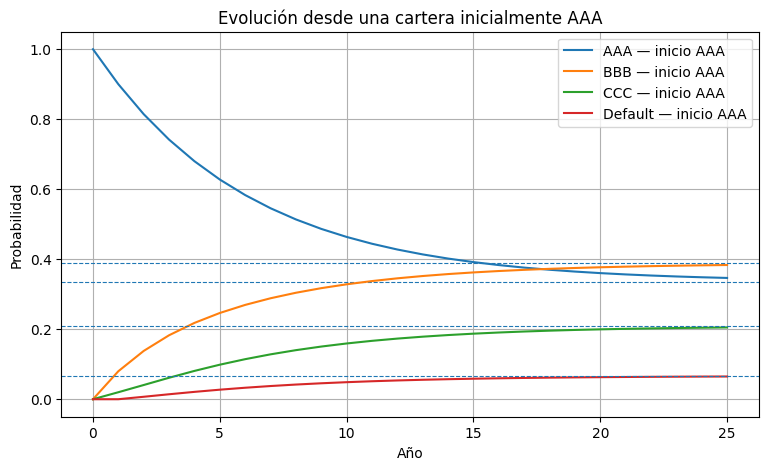

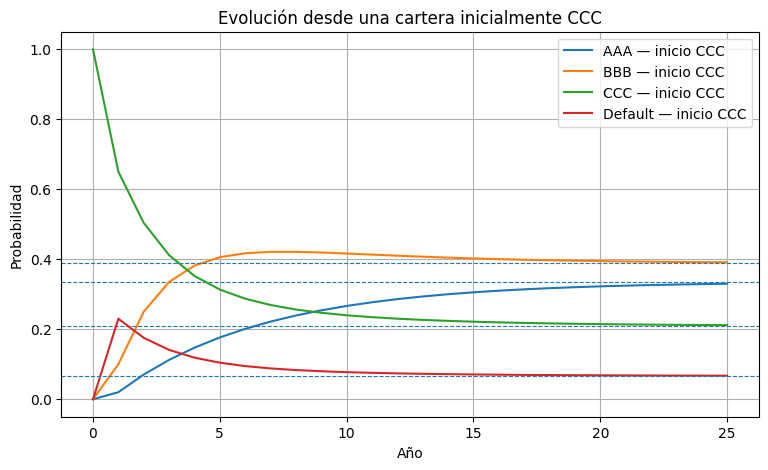

In [15]:
plt.figure(figsize=(9, 5))

for indice_rating in range(numero_ratings):
    plt.plot(
        evolucion_desde_aaa[:, indice_rating],
        label=ratings[indice_rating] + " — inicio AAA"
    )

    # La línea horizontal permite comparar la evolución con la distribución estacionaria.
    plt.axhline(
        pi_credito_estacionaria[indice_rating],
        linestyle='--',
        linewidth=0.8
    )

plt.xlabel("Año")
plt.ylabel("Probabilidad")
plt.title("Evolución desde una cartera inicialmente AAA")
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(9, 5))

for indice_rating in range(numero_ratings):
    plt.plot(
        evolucion_desde_ccc[:, indice_rating],
        label=ratings[indice_rating] + " — inicio CCC"
    )

    # La línea horizontal permite comparar la evolución con la distribución estacionaria.
    plt.axhline(
        pi_credito_estacionaria[indice_rating],
        linestyle='--',
        linewidth=0.8
    )

plt.xlabel("Año")
plt.ylabel("Probabilidad")
plt.title("Evolución desde una cartera inicialmente CCC")
plt.legend()
plt.grid()
plt.show()

**f)** El banco negocia mejores condiciones de reestructuración y modifica la fila correspondiente a Default:

$$
P'_{3\cdot}=[0.30,\;0.50,\;0.15,\;0.05].
$$

Calcule la nueva pérdida esperada y compárela con la original.

In [16]:
P_credito_reestructuracion = P_credito.copy()

# Modificamos las transiciones desde el estado CCC
# para representar la política de reestructuración.
P_credito_reestructuracion[3, :] = [
    0.30, 0.50, 0.15, 0.05
]

pi_reestructuracion_anterior = np.array([
    0.25, 0.25, 0.25, 0.25
])

for iteracion in range(1, maximo_iteraciones + 1):
    pi_reestructuracion_nueva = (
        pi_reestructuracion_anterior
        @ P_credito_reestructuracion
    )

    # Medimos el mayor cambio entre iteraciones consecutivas
    # para determinar cuándo se alcanza la distribución estacionaria.
    cambio_maximo = np.max(
        np.abs(
            pi_reestructuracion_nueva
            - pi_reestructuracion_anterior
        )
    )

    pi_reestructuracion_anterior = (
        pi_reestructuracion_nueva
    )

    if cambio_maximo < tolerancia:
        break

pi_credito_reestructuracion = (
    pi_reestructuracion_anterior
)

# Calculamos la pérdida esperada bajo la nueva política
# usando la distribución estacionaria obtenida.
perdida_reestructuracion = (
    pi_credito_reestructuracion @ perdidas
)

print(
    "Pérdida esperada original:",
    round(perdida_esperada_credito, 6)
)

print(
    "Pérdida esperada con reestructuración:",
    round(perdida_reestructuracion, 6)
)

print(
    "Reducción absoluta:",
    round(
        perdida_esperada_credito
        - perdida_reestructuracion,
        6
    )
)

Pérdida esperada original: 0.036713
Pérdida esperada con reestructuración: 0.031137
Reducción absoluta: 0.005576


**Verificación con `jmarkov`.**

In [17]:
cadena_credito = dtmc(P_credito)

cadena_credito_reestructuracion = dtmc(
    P_credito_reestructuracion
)

print(
    "Cadena original ergódica:",
    cadena_credito.is_ergodic()
)

print(
    "Cadena original irreducible:",
    cadena_credito.is_irreducible()
)

print(
    "Período:",
    cadena_credito.period()
)

pi_credito_jmarkov = (
    cadena_credito.steady_state()
)

pi_reestructuracion_jmarkov = (
    cadena_credito_reestructuracion.steady_state()
)

print()
print(
    "pi original con NumPy:",
    np.round(pi_credito_estacionaria, 4)
)

print(
    "pi original con jmarkov:",
    np.round(pi_credito_jmarkov, 4)
)

print(
    "pi reestructuración con NumPy:",
    np.round(pi_credito_reestructuracion, 4)
)

print(
    "pi reestructuración con jmarkov:",
    np.round(pi_reestructuracion_jmarkov, 4)
)

Cadena original ergódica: True
Cadena original irreducible: True
Período: 1

pi original con NumPy: [0.3358 0.3885 0.2093 0.0664]
pi original con jmarkov: [0.3358 0.3885 0.2093 0.0664]
pi reestructuración con NumPy: [0.3892 0.3802 0.176  0.0546]
pi reestructuración con jmarkov: [0.3892 0.3802 0.176  0.0546]


---
## Ejercicio 3 — Ciclo de vida de un cliente de comercio electrónico *(reto guiado)*

Una aplicación representa a cada cliente mediante el número de días transcurridos desde su última compra:

$$
X_n=\text{días desde la última compra al final del día }n,
\qquad
\mathcal{S}=\{0,1,\ldots,30\}.
$$

Los clientes se clasifican así:

- **Activos:** estados 0 a 6, con probabilidad de compra $p_1=0.30$.
- **Inactivos:** estados 7 a 29, con probabilidad de compra $p_2=0.18$.
- **Perdidos:** estado 30, con probabilidad de compra $p_3=0.10$.

Si el cliente compra, regresa al estado 0. Si no compra, avanza un día. Desde el estado 30, si no compra, permanece en 30.

La campaña entrega diariamente:

- **$10 000** a cada cliente activo;
- **$3 000** a cada cliente inactivo;
- **$0** a cada cliente perdido.

En este ejercicio no escribiremos directamente las 31 filas. Primero construiremos una fila representativa de cada grupo y después generalizaremos la regla mediante un ciclo.

### a.1) Comprender tres filas representativas

Construya las transiciones desde los estados 3, 10 y 30. Observe que cada fila solo tiene dos probabilidades distintas de cero.

In [18]:
p_activo = 0.30
p_inactivo = 0.18
p_perdido = 0.10

numero_estados_clientes = 31

fila_desde_3 = np.zeros(numero_estados_clientes)
fila_desde_3[0] = p_activo
fila_desde_3[4] = 1 - p_activo

fila_desde_10 = np.zeros(numero_estados_clientes)
fila_desde_10[0] = p_inactivo
fila_desde_10[11] = 1 - p_inactivo

fila_desde_30 = np.zeros(numero_estados_clientes)
fila_desde_30[0] = p_perdido
fila_desde_30[30] = 1 - p_perdido

print("Suma de la fila desde 3:", fila_desde_3.sum())
print("Suma de la fila desde 10:", fila_desde_10.sum())
print("Suma de la fila desde 30:", fila_desde_30.sum())

Suma de la fila desde 3: 1.0
Suma de la fila desde 10: 1.0
Suma de la fila desde 30: 1.0


### a.2) Generalizar la regla

Ahora construiremos la matriz completa. El código utiliza únicamente ciclos y condicionales ordinarios.

Observe especialmente el tratamiento del estado 30: el siguiente estado no puede ser 31.

In [19]:
P_clientes = np.zeros((
    numero_estados_clientes,
    numero_estados_clientes
))

for estado_actual in range(numero_estados_clientes):

    if estado_actual <= 6:
        probabilidad_compra = p_activo

    elif estado_actual <= 29:
        probabilidad_compra = p_inactivo

    else:
        probabilidad_compra = p_perdido

    P_clientes[
        estado_actual, 0
    ] = probabilidad_compra

    if estado_actual < 30:
        estado_si_no_compra = estado_actual + 1

    else:
        estado_si_no_compra = 30

    P_clientes[
        estado_actual,
        estado_si_no_compra
    ] = 1 - probabilidad_compra

print("Dimensión de P:", P_clientes.shape)

filas_validas = True

for estado_actual in range(numero_estados_clientes):
    suma_fila = P_clientes[estado_actual, :].sum()

    if abs(suma_fila - 1.0) > 0.000001:
        filas_validas = False

print("Todas las filas suman 1:", filas_validas)

print()
print(
    "La fila 3 coincide con el ejemplo:",
    np.allclose(P_clientes[3, :], fila_desde_3)
)

print(
    "La fila 10 coincide con el ejemplo:",
    np.allclose(P_clientes[10, :], fila_desde_10)
)

print(
    "La fila 30 coincide con el ejemplo:",
    np.allclose(P_clientes[30, :], fila_desde_30)
)

Dimensión de P: (31, 31)
Todas las filas suman 1: True

La fila 3 coincide con el ejemplo: True
La fila 10 coincide con el ejemplo: True
La fila 30 coincide con el ejemplo: True


**b)** Calcule la distribución estacionaria. Después agregue sus componentes para obtener la fracción de clientes activos, inactivos y perdidos.

En lugar de utilizar cortes compactos del arreglo, realizaremos las sumas mediante ciclos explícitos.

In [20]:
pi_clientes_anterior = (
    np.ones(numero_estados_clientes)
    / numero_estados_clientes
)

tolerancia_clientes = 0.000000001
maximo_iteraciones_clientes = 3000

for iteracion in range(
    1,
    maximo_iteraciones_clientes + 1
):
    pi_clientes_nueva = (
        pi_clientes_anterior @ P_clientes
    )

    cambio_maximo = np.max(
        np.abs(
            pi_clientes_nueva
            - pi_clientes_anterior
        )
    )

    pi_clientes_anterior = pi_clientes_nueva

    if cambio_maximo < tolerancia_clientes:
        break

pi_clientes_estacionaria = pi_clientes_anterior

fraccion_activos = 0.0

for estado in range(0, 7):
    fraccion_activos = (
        fraccion_activos
        + pi_clientes_estacionaria[estado]
    )

fraccion_inactivos = 0.0

for estado in range(7, 30):
    fraccion_inactivos = (
        fraccion_inactivos
        + pi_clientes_estacionaria[estado]
    )

fraccion_perdidos = (
    pi_clientes_estacionaria[30]
)

print("Iteraciones hasta convergencia:", iteracion)
print("Fracción de clientes activos:", round(fraccion_activos, 4))
print("Fracción de clientes inactivos:", round(fraccion_inactivos, 4))
print("Fracción de clientes perdidos:", round(fraccion_perdidos, 4))

print(
    "Suma de las tres fracciones:",
    round(
        fraccion_activos
        + fraccion_inactivos
        + fraccion_perdidos,
        4
    )
)

Iteraciones hasta convergencia: 159
Fracción de clientes activos: 0.8689
Fracción de clientes inactivos: 0.1286
Fracción de clientes perdidos: 0.0024
Suma de las tres fracciones: 1.0


**c)** Calcule el costo esperado diario de los incentivos:

$$
\mathbb{E}[\text{costo}]
=
\sum_i\pi_i f(i).
$$

Primero construiremos el vector de incentivos mediante un ciclo. Después calcularemos la suma componente por componente.

In [21]:
incentivo_por_estado = np.zeros(
    numero_estados_clientes
)

for estado in range(numero_estados_clientes):

    if estado <= 6:
        incentivo_por_estado[estado] = 10_000

    elif estado <= 29:
        incentivo_por_estado[estado] = 3_000

    else:
        incentivo_por_estado[estado] = 0

costo_diario_incentivos = 0.0

for estado in range(numero_estados_clientes):
    costo_diario_incentivos = (
        costo_diario_incentivos
        + pi_clientes_estacionaria[estado]
        * incentivo_por_estado[estado]
    )

print(
    "Costo esperado diario de incentivos: $",
    round(costo_diario_incentivos, 2)
)

Costo esperado diario de incentivos: $ 9075.3


**d)** Se observa un cliente que realizó una compra hace 3 días, por lo que $X_0=3$. Calcule la probabilidad de que dentro de 7 días se encuentre inactivo.

In [22]:
pi0_cliente_dia3 = np.zeros(
    numero_estados_clientes
)

pi0_cliente_dia3[3] = 1.0

pi7_cliente = pi0_cliente_dia3.copy()

for dia in range(7):
    pi7_cliente = pi7_cliente @ P_clientes

probabilidad_inactivo_dia7 = 0.0

for estado in range(7, 30):
    probabilidad_inactivo_dia7 = (
        probabilidad_inactivo_dia7
        + pi7_cliente[estado]
    )

print(
    "P(cliente inactivo en 7 días | X0 = 3) =",
    round(probabilidad_inactivo_dia7, 4)
)

P(cliente inactivo en 7 días | X0 = 3) = 0.1324


**e)** Una nueva campaña aumenta la probabilidad de compra de los clientes activos a

$$
p_1'=0.45.
$$

Construya la nueva matriz y compare:

1. la fracción de clientes activos a largo plazo;
2. el costo diario esperado de los incentivos.

> Una mayor proporción de clientes activos no demuestra por sí sola que la campaña sea económicamente conveniente. Para decidirlo también se necesitarían el costo de implementar la campaña y el margen generado por las compras adicionales.

In [23]:
p_activo_nueva_campana = 0.45

P_clientes_nueva = np.zeros((
    numero_estados_clientes,
    numero_estados_clientes
))

for estado_actual in range(numero_estados_clientes):

    if estado_actual <= 6:
        probabilidad_compra = (
            p_activo_nueva_campana
        )

    elif estado_actual <= 29:
        probabilidad_compra = p_inactivo

    else:
        probabilidad_compra = p_perdido

    P_clientes_nueva[
        estado_actual, 0
    ] = probabilidad_compra

    if estado_actual < 30:
        estado_si_no_compra = estado_actual + 1

    else:
        estado_si_no_compra = 30

    P_clientes_nueva[
        estado_actual,
        estado_si_no_compra
    ] = 1 - probabilidad_compra

pi_clientes_nueva_anterior = (
    np.ones(numero_estados_clientes)
    / numero_estados_clientes
)

for iteracion in range(
    1,
    maximo_iteraciones_clientes + 1
):
    pi_clientes_nueva_actual = (
        pi_clientes_nueva_anterior
        @ P_clientes_nueva
    )

    cambio_maximo = np.max(
        np.abs(
            pi_clientes_nueva_actual
            - pi_clientes_nueva_anterior
        )
    )

    pi_clientes_nueva_anterior = (
        pi_clientes_nueva_actual
    )

    if cambio_maximo < tolerancia_clientes:
        break

pi_clientes_nueva_estacionaria = (
    pi_clientes_nueva_anterior
)

fraccion_activos_nueva = 0.0

for estado in range(0, 7):
    fraccion_activos_nueva = (
        fraccion_activos_nueva
        + pi_clientes_nueva_estacionaria[estado]
    )

costo_diario_nuevo = 0.0

for estado in range(numero_estados_clientes):
    costo_diario_nuevo = (
        costo_diario_nuevo
        + pi_clientes_nueva_estacionaria[estado]
        * incentivo_por_estado[estado]
    )

print(
    "Fracción de activos — original:",
    round(fraccion_activos, 4)
)

print(
    "Fracción de activos — nueva campaña:",
    round(fraccion_activos_nueva, 4)
)

print(
    "Costo diario — original: $",
    round(costo_diario_incentivos, 2)
)

print(
    "Costo diario — nueva campaña: $",
    round(costo_diario_nuevo, 2)
)

Fracción de activos — original: 0.8689
Fracción de activos — nueva campaña: 0.9625
Costo diario — original: $ 9075.3
Costo diario — nueva campaña: $ 9735.34


**Verificación con `jmarkov`.**

Para evitar una salida excesivamente larga, compararemos solamente los primeros cinco estados, uno por uno.

In [24]:
cadena_clientes = dtmc(P_clientes)
cadena_clientes_nueva = dtmc(P_clientes_nueva)

print(
    "Cadena original ergódica:",
    cadena_clientes.is_ergodic()
)

pi_clientes_jmarkov = (
    cadena_clientes.steady_state()
)

pi7_cliente_jmarkov = (
    cadena_clientes.transient_probabilities(
        n=7,
        alpha=pi0_cliente_dia3
    )
)

pi_clientes_nueva_jmarkov = (
    cadena_clientes_nueva.steady_state()
)

print()
print("Comparación de los primeros cinco estados:")

for estado in range(5):
    print(
        "Estado", estado,
        "- NumPy:", round(
            pi_clientes_estacionaria[estado],
            4
        ),
        "- jmarkov:", round(
            pi_clientes_jmarkov[estado],
            4
        )
    )

print()
print(
    "pi(7) con NumPy:",
    np.round(pi7_cliente, 4)
)

print(
    "pi(7) con jmarkov:",
    np.round(pi7_cliente_jmarkov, 4)
)

print()
print(
    "Nueva campaña coincide:",
    np.allclose(
        pi_clientes_nueva_estacionaria,
        pi_clientes_nueva_jmarkov
    )
)

Cadena original ergódica: True

Comparación de los primeros cinco estados:
Estado 0 - NumPy: 0.2841 - jmarkov: 0.2841
Estado 1 - NumPy: 0.1989 - jmarkov: 0.1989
Estado 2 - NumPy: 0.1392 - jmarkov: 0.1392
Estado 3 - NumPy: 0.0974 - jmarkov: 0.0974
Estado 4 - NumPy: 0.0682 - jmarkov: 0.0682

pi(7) con NumPy: [0.2806 0.1935 0.1329 0.1029 0.072  0.0504 0.0353 0.     0.     0.
 0.1324 0.     0.     0.     0.     0.     0.     0.     0.     0.
 0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
 0.    ]
pi(7) con jmarkov: [0.2806 0.1935 0.1329 0.1029 0.072  0.0504 0.0353 0.     0.     0.
 0.1324 0.     0.     0.     0.     0.     0.     0.     0.     0.
 0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
 0.    ]

Nueva campaña coincide: True


---
## Ejercicio 4 — Ocupación de un hub logístico *(ejercicio abierto con apoyo de IA)*

Un centro de distribución tiene capacidad para almacenar hasta **4 camiones**. En cada hora ocurre uno de los siguientes eventos:

- llega un camión con probabilidad $\alpha=0.5$;
- sale un camión con probabilidad $\beta=0.4$;
- no hay movimiento con probabilidad $0.1$.

Cuando el hub está vacío no puede salir un camión. Cuando está lleno, las nuevas llegadas se pierden.

$$
X_n=\text{número de camiones en el hub en la hora }n,
\qquad
\mathcal{S}=\{0,1,2,3,4\}.
$$

### Reglas que deben derivarse antes de programar

- Desde 0: puede permanecer en 0 o pasar a 1.
- Desde 1, 2 o 3: puede disminuir uno, permanecer igual o aumentar uno.
- Desde 4: puede pasar a 3 o permanecer en 4.

### Tareas

1. Construya la matriz de transición y verifique que todas las filas sumen 1.
2. Calcule la distribución estacionaria e interprete $\pi_0$ y $\pi_4$.
3. Calcule la utilización esperada:
   $$
   \mathbb{E}[X]=\sum_{i=0}^{4}i\pi_i.
   $$
4. Partiendo del hub vacío, calcule en cada hora
   $$
   d(n)=\max_i|\pi_i(n)-\pi_i|
   $$
   y reporte la primera hora para la cual $d(n)<0.01$.
5. Verifique los resultados con `jmarkov`.
6. Grafique la evolución de las probabilidades. El código específico de Matplotlib no será evaluado.

### Paso 1 — Obtenga una referencia antes de consultar la IA

Construya la matriz mediante las reglas anteriores y calcule $\boldsymbol{\pi}(2)$ partiendo del hub vacío. Esta referencia es más informativa que $\boldsymbol{\pi}(1)$ porque requiere considerar caminos de dos pasos.

In [25]:
alpha_hub = 0.5
beta_hub = 0.4
probabilidad_sin_movimiento = 0.1

P_hub = np.zeros((5, 5))

# Estado vacío
P_hub[0, 0] = 1 - alpha_hub
P_hub[0, 1] = alpha_hub

# Estados intermedios
for estado in range(1, 4):
    P_hub[estado, estado - 1] = beta_hub

    P_hub[
        estado, estado
    ] = probabilidad_sin_movimiento

    P_hub[estado, estado + 1] = alpha_hub

# Estado lleno
P_hub[4, 3] = beta_hub
P_hub[4, 4] = 1 - beta_hub

filas_hub_validas = True

for estado in range(5):
    suma_fila = P_hub[estado, :].sum()

    if abs(suma_fila - 1.0) > 0.000001:
        filas_hub_validas = False

print("Todas las filas suman 1:", filas_hub_validas)
print(P_hub)

pi0_hub = np.array([1.0, 0.0, 0.0, 0.0, 0.0])

pi1_hub = pi0_hub @ P_hub
pi2_hub = pi1_hub @ P_hub

print()
print("pi(1):", np.round(pi1_hub, 4))
print("pi(2):", np.round(pi2_hub, 4))

print(
    "Referencia: P(X2 = 2 | X0 = 0) =",
    round(pi2_hub[2], 4)
)

Todas las filas suman 1: True
[[0.5 0.5 0.  0.  0. ]
 [0.4 0.1 0.5 0.  0. ]
 [0.  0.4 0.1 0.5 0. ]
 [0.  0.  0.4 0.1 0.5]
 [0.  0.  0.  0.4 0.6]]

pi(1): [0.5 0.5 0.  0.  0. ]
pi(2): [0.45 0.3  0.25 0.   0.  ]
Referencia: P(X2 = 2 | X0 = 0) = 0.25


### Paso 2 — Construya cuidadosamente el prompt

El prompt debe incluir las reglas de transición ya derivadas. También debe exigir código sencillo, coherente con el nivel del curso.

Puede utilizar el siguiente:

```text
Estoy modelando la ocupación de un hub logístico como una cadena de Markov
a tiempo discreto.

Convención:
P[i,j] = P(X_{n+1}=j | X_n=i).
Los estados son 0, 1, 2, 3 y 4 camiones.

Parámetros:
alpha = 0.5 para una llegada,
beta = 0.4 para una salida,
y 0.1 para que no haya movimiento.

Reglas:
- Desde 0: P[0,0] = 1-alpha y P[0,1] = alpha.
- Desde 1, 2 y 3:
  P[i,i-1] = beta,
  P[i,i] = 0.1,
  P[i,i+1] = alpha.
- Desde 4: P[4,3] = beta y P[4,4] = 1-beta.

Ayúdame a:

1. Construir la matriz P con NumPy y verificar fila por fila que suma 1.
2. Calcular la distribución estacionaria repitiendo pi_nueva = pi_anterior @ P
   hasta que el cambio máximo sea menor que 0.00000001.
3. Interpretar pi[0] y pi[4].
4. Calcular E[X] mediante un ciclo for.
5. Partiendo de pi(0) = [1,0,0,0,0], calcular la evolución hasta 50 horas.
6. En cada hora calcular max(abs(pi_n - pi_estacionaria)) y reportar
   la primera hora en la que ese valor sea menor que 0.01.
7. Verificar la distribución estacionaria con jmarkov.
8. Generar una gráfica de la evolución de las cinco probabilidades.

Usa ciclos for y condicionales ordinarios.
No uses comprensiones de listas, enumerate, zip ni diccionarios.
Separa el cálculo de la visualización y comenta brevemente cada bloque.
```

Antes de aceptar la respuesta, compruebe que reproduzca:

$$
P(X_2=2\mid X_0=0)=0.25.
$$

In [26]:
# Pegue aquí el código computacional generado por la IA.
#
# Antes de continuar, compruebe:
# 1. que la matriz obtenida coincida con P_hub;
# 2. que pi(2)[2] sea igual a 0.25;
# 3. que la IA haya calculado explícitamente la primera
#    hora para la que la distancia sea menor que 0.01.

### 🎨 Visualización proporcionada

La gráfica no constituye un objetivo de programación de esta semana. Después de obtener una matriz llamada `evolucion_hub`, con una fila por hora y una columna por estado, puede adaptar y ejecutar la siguiente celda.

Copie y adapte este bloque después de que su solución haya creado `evolucion_hub`:

```python
plt.figure(figsize=(9, 5))

for estado in range(5):
    plt.plot(
        evolucion_hub[:, estado],
        label="Estado " + str(estado)
    )

plt.xlabel("Hora")
plt.ylabel("Probabilidad")
plt.title("Evolución de la ocupación del hub")
plt.legend()
plt.grid()
plt.show()
```

Si la IA utilizó otro nombre para la matriz de evolución, reemplácelo en el código.

---
<small>Universidad de los Andes · Departamento de Ingeniería Industrial · Modelos de Decisión en el Tiempo</small>